In [ ]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import scipy as sc

from potential import WolfeQuapp

from mcmc import mcmc_propagate
from util import correlate, effective_sample_size

from wq_estimate_committor import wq_order_param_linear, wq_order_param_circle, q_A_B_from_R
from tps import load_umbrella_sampling_samples, generate_reactive_paths_brownian

TO_CM = 1/2.54
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 10
})

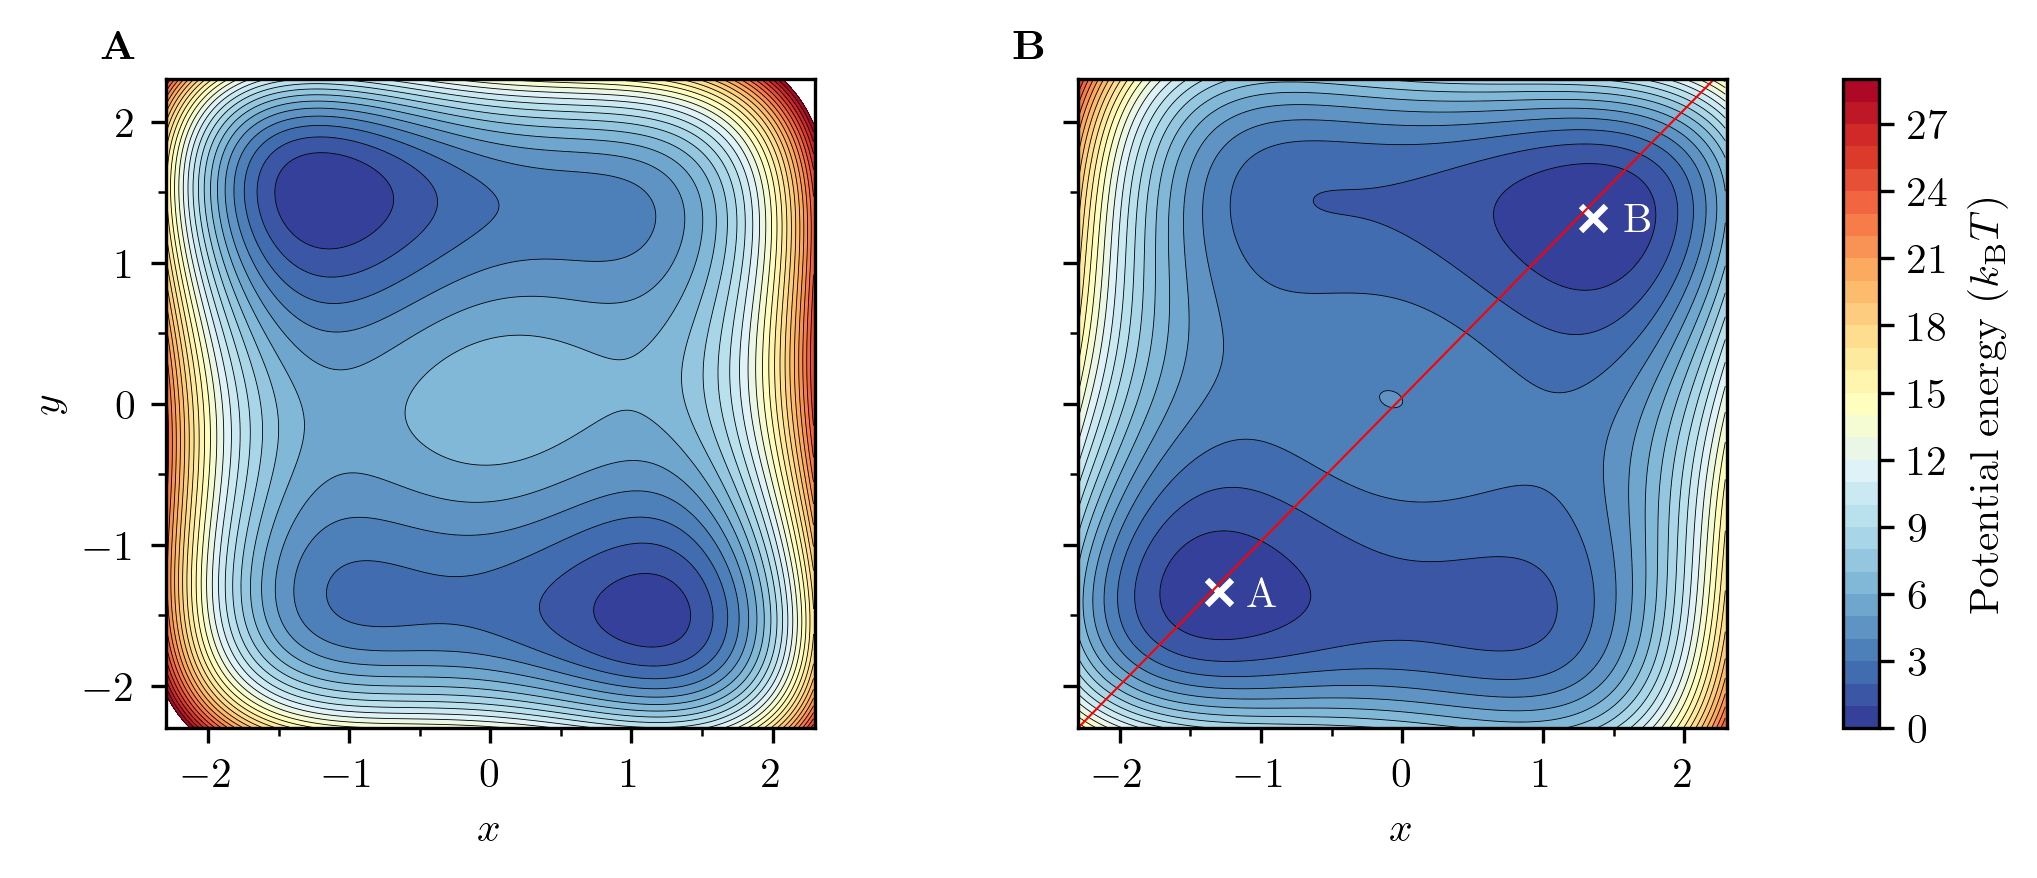

In [ ]:
h = 4.0
potential = WolfeQuapp(h=h)

xmax = 2.3
ymax = xmax
levels = np.arange(0, 30, 1)

x = np.arange(-xmax, xmax, 0.01)
y = np.arange(-ymax, ymax, 0.01)
xv, yv = np.meshgrid(x, y)

not_rotated = lambda x, y: x**4 + y**4 - 2*x**2 - 4*y**2 + x*y + 0.3*x + 0.1*y

potential_values_not_rotated = not_rotated(np.vstack([xv.flatten(), yv.flatten()]).T[..., 0], np.vstack([xv.flatten(), yv.flatten()]).T[..., 1]).reshape(xv.shape)
potential_values_not_rotated -= np.min(potential_values_not_rotated)

potential_values = potential.evaluate(np.vstack([xv.flatten(), yv.flatten()]).T).reshape(xv.shape)

fig_width = 17.59
margin_left = 1.25
cbar_gap = 0.3
cbar_width = 0.3
margin_right = 1.15 
panel_gap = 0.85
panel_width = (fig_width - margin_left - panel_gap - cbar_gap - cbar_width - margin_right) / 2
panel_height = panel_width/1.25
margin_top = 0.5
margin_bottom = 1.15
fig_height = margin_top + panel_height + margin_bottom

rect = lambda x0, y0, width, height: (x0/fig_width, y0/fig_height, width/fig_width, height/fig_height)

fig = plt.figure(figsize=(fig_width * TO_CM, fig_height * TO_CM), dpi=300)

panel_lefts = [margin_left, margin_left + panel_width + panel_gap]

ax0 = fig.add_axes(rect(panel_lefts[0], margin_bottom, panel_width, panel_height))
ax1 = fig.add_axes(rect(panel_lefts[1], margin_bottom, panel_width, panel_height))

cax_pes = fig.add_axes(rect(panel_lefts[1] + panel_width + cbar_gap, margin_bottom, cbar_width, panel_height))

ax1.sharex(ax0)
ax1.sharey(ax0)

contour0 = ax0.contourf(xv, yv, potential_values_not_rotated, cmap="RdYlBu_r", levels=levels)
contour1 = ax1.contourf(xv, yv, potential_values, cmap="RdYlBu_r", levels=levels)

ax0.contour(xv, yv, potential_values_not_rotated, levels=levels, colors="black", linewidths=0.2)
ax1.contour(xv, yv, potential_values, levels=levels, colors="black", linewidths=0.2)

ax1.scatter(*potential.A, color="white", marker="x")
ax1.text(potential.A[0] + 0.2, potential.A[1] -0.1, "A", color="white")

ax1.scatter(*potential.B, color="white", marker="x")
ax1.text(potential.B[0]+0.22, potential.B[1] - 0.1, "B", color="white")

ax1.plot([-2.3, 2.2], [-2.3, 2.29], color="red", lw=0.5)

cbar = fig.colorbar(contour0, cax=cax_pes, orientation="vertical")
cbar.set_label(r"Potential energy ($k_{\mathrm{B}} T$)")

for a, panel_label in zip([ax0, ax1], ["A", "B"]):
    a.set_xlim((-xmax, xmax))
    a.set_ylim((-ymax, ymax))
    a.set_aspect('equal', adjustable='box')
    a.set_xlabel("$x$")
    a.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
    a.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
    a.text(-0.1, 1.02, rf"\textbf{{{panel_label}}}", transform=a.transAxes, ha="left", va="bottom")

ax0.set_ylabel("$y$")

ax1.set_ylabel("")
ax1.tick_params(axis="y", labelleft=False)

plt.show()

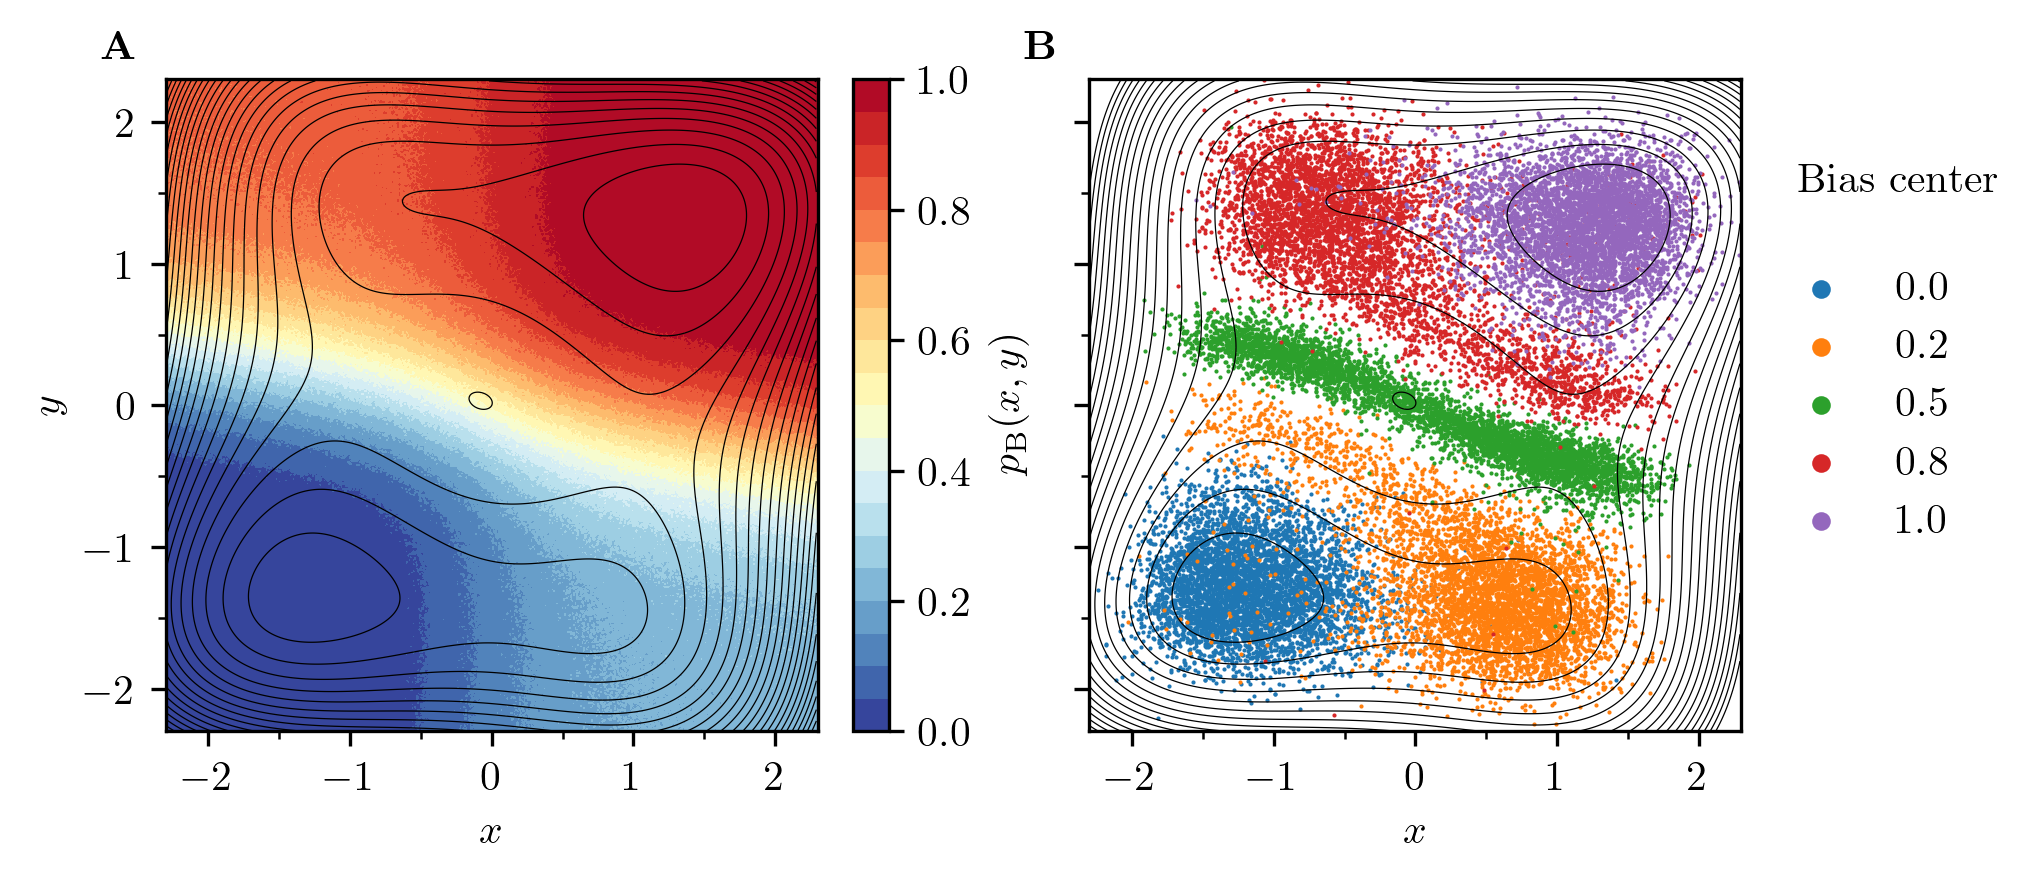

In [ ]:
q_A = q_A_B_from_R("A", 0.5, potential)
q_B = q_A_B_from_R("B", 0.5, potential)

param_dict = {"max": 2.3, "dx": 0.01, "ntrajectories" : 1000, "h": h, "qa": q_A, "qb": q_B, "target": "B", "timestep": 1e-2, "diffusioncoeff": 1.0, "orderparam": "circular"}

filename = "committor_estimates/wq"
for param_name, param in param_dict.items():
    filename += f"_{param_name}_{param}"
filename += ".csv"

committor_estimates = np.loadtxt(filename, delimiter=",")

side_length = int(np.sqrt(len(committor_estimates)))
sort_args = np.argsort(committor_estimates[:, 0]*side_length + committor_estimates[:, 1])

committor_estimates = committor_estimates[sort_args]

X = committor_estimates[:, 0].reshape(side_length, side_length).T
Y = committor_estimates[:, 1].reshape(side_length, side_length).T
committor_values = committor_estimates[:, 2].reshape(side_length, side_length).T

loaded_samples, bias_centers = load_umbrella_sampling_samples("samples/wq_us_h_4.0_nwindows_11_nsamples_10000_orderparam_circular.csv")
example_bias_centers = [0.0, 0.2, 0.5, 0.8, 1.0]

fig_width = 17.59
margin_left = 1.25
cbar_gap = 0.3
cbar_width = 0.3
gap_after_cbar = 1.7
right_margin = 3.0
panel_width = (fig_width - margin_left - cbar_gap - cbar_width - gap_after_cbar - right_margin) / 2
panel_height = panel_width
margin_top = 0.5
margin_bottom = 1.15
fig_height = margin_top + panel_height + margin_bottom

rect = lambda x0, y0, width, height: (x0/fig_width, y0/fig_height, width/fig_width, height/fig_height)

fig = plt.figure(figsize=(fig_width * TO_CM, fig_height * TO_CM), dpi=300)

left_A = margin_left
left_cbar = left_A + panel_width + cbar_gap
left_B = left_cbar + cbar_width + gap_after_cbar

ax0 = fig.add_axes(rect(left_A, margin_bottom, panel_width, panel_height))
cax_committor = fig.add_axes(rect(left_cbar, margin_bottom, cbar_width, panel_height))
ax1 = fig.add_axes(rect(left_B, margin_bottom, panel_width, panel_height))

ax1.sharex(ax0)
ax1.sharey(ax0)

potential.plot_PES(fig, ax0, title="", fill=False, plot_clabels=False)

contour = ax0.contourf(X, Y, committor_values, cmap="RdYlBu_r", vmin=0, vmax=1, levels=np.linspace(0, 1, 21))

cbar_committor = fig.colorbar(contour, cax=cax_committor, orientation="vertical", ticks=np.arange(0, 1.01, 0.2), format="%.1f")
cbar_committor.set_label(r"$p_{\mathrm{B}}(x, y)$")

potential.plot_PES(fig, ax1, fill=False, levels=np.arange(0, 20, 1), plot_clabels=False)

for loaded_sample, bias_center in zip(loaded_samples, bias_centers):
    if bias_center not in example_bias_centers:
        continue
    ax1.scatter(loaded_sample[:5000, 0], loaded_sample[:5000, 1], s=1, label=f"{bias_center:0.1f}", linewidth=0)

leg = ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
for handle in leg.legend_handles:
    handle._sizes = [20]

ax1.text(2.7, 1.5, "Bias center")

for a, panel_label in zip([ax0, ax1], ["A", "B"]):
    a.set_xlim((-xmax, xmax))
    a.set_ylim((-ymax, ymax))
    a.set_aspect('equal', adjustable='box')
    a.set_xlabel("$x$")
    a.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
    a.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
    a.text(-0.1, 1.02, rf"\textbf{{{panel_label}}}", transform=a.transAxes, ha="left", va="bottom")

ax0.set_ylabel("$y$")

ax1.set_ylabel("")
ax1.tick_params(axis="y", labelleft=False)

plt.show()

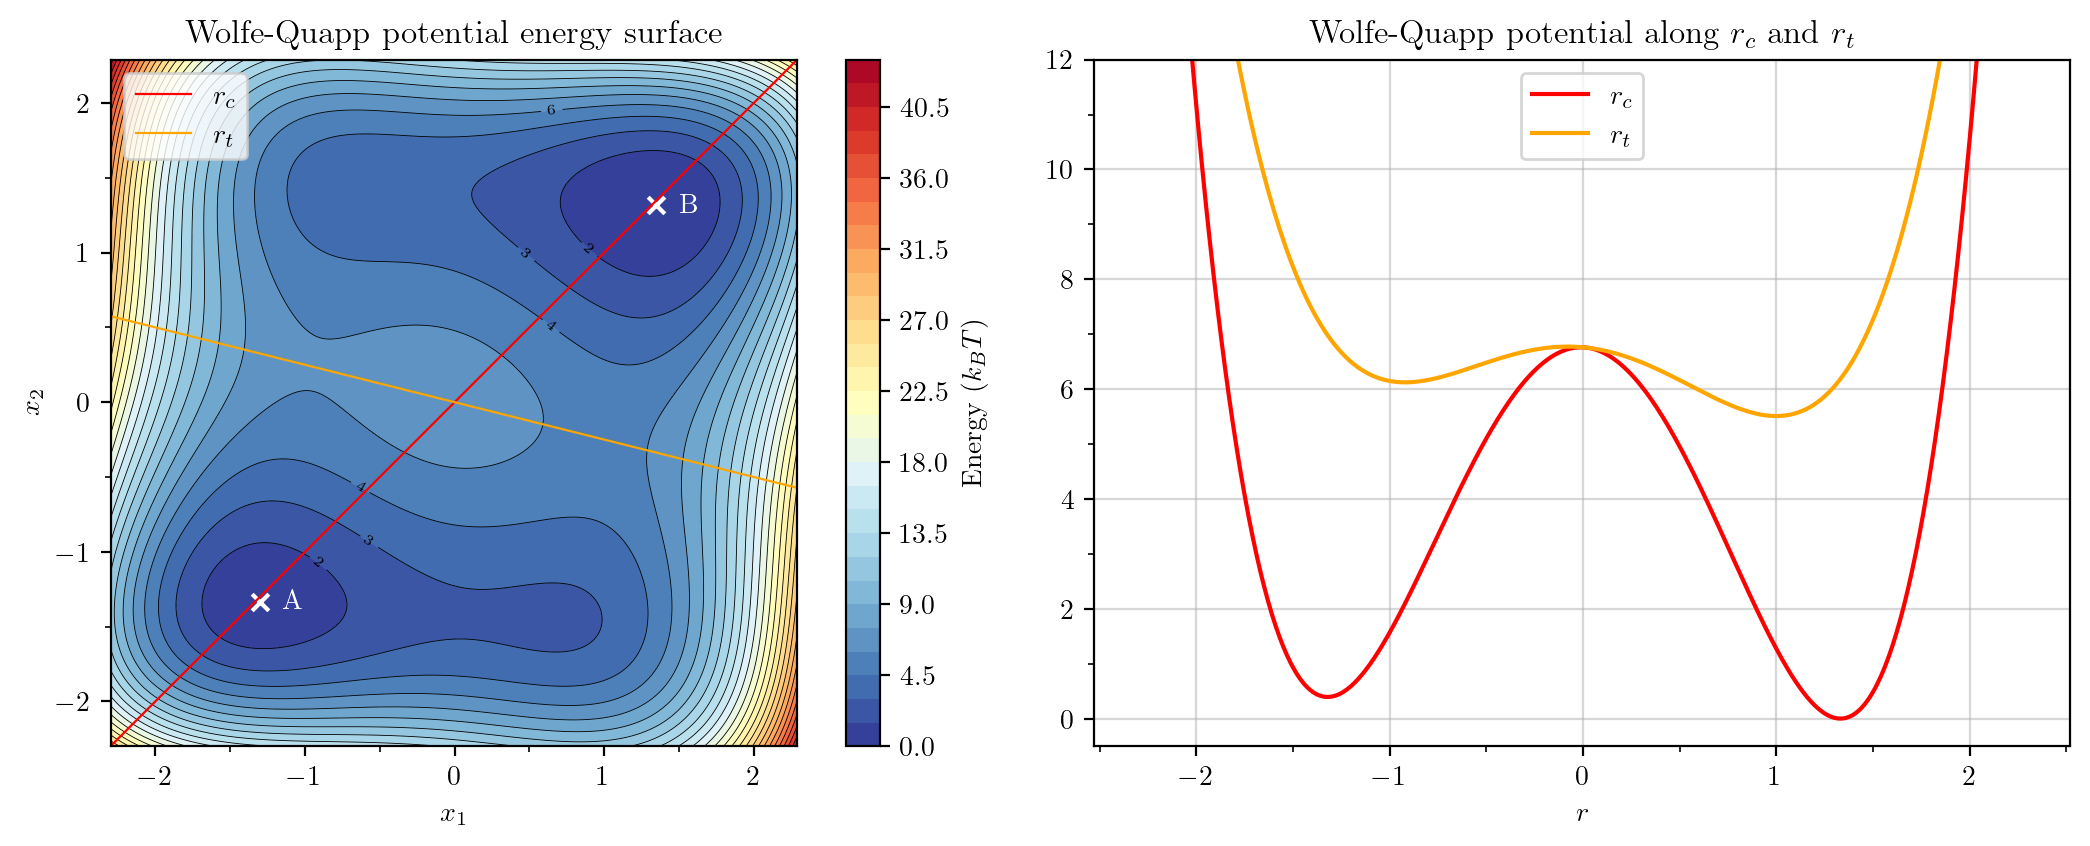

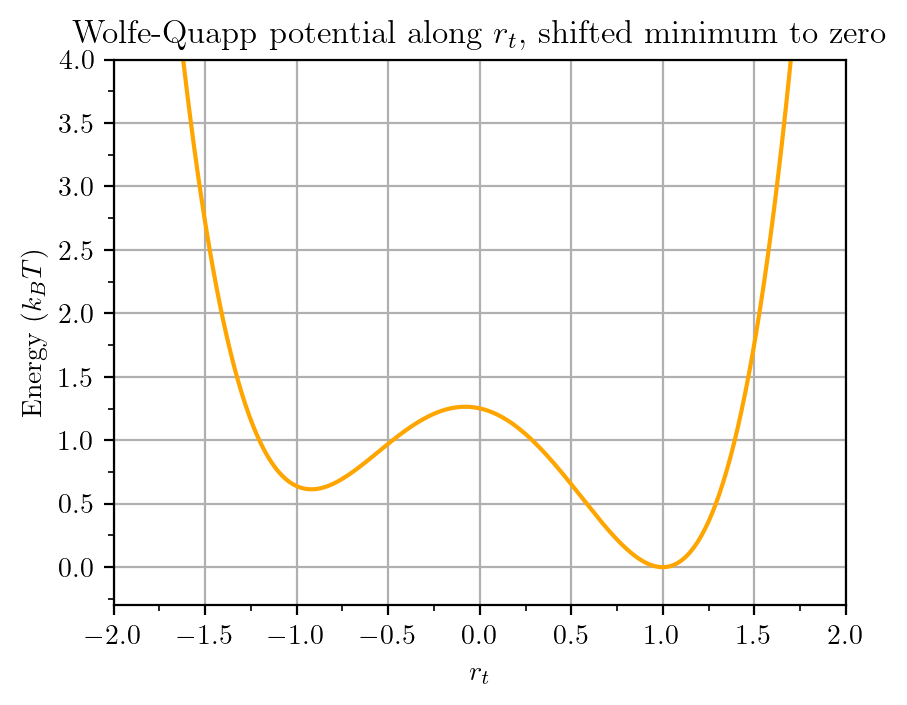

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(28*TO_CM, 11*TO_CM), dpi=200)

xmax = 2.3
ymax = xmax

x = np.arange(-xmax, xmax, 0.01)
y = np.arange(-ymax, ymax, 0.01)

potential = WolfeQuapp()

potential.plot_PES(fig, ax[0], xmin=-xmax, xmax=xmax, ymin=-ymax, ymax=ymax, levels=30, plot_labels=True, title="Wolfe-Quapp potential energy surface")

ax[0].plot(x, x, color="red", lw=0.8, label="$r_c$")
ax[0].plot(x, -0.25*x, color="orange", lw=0.8, label="$r_t$")

ax[0].legend()

rc_potential_values = potential.evaluate(np.vstack([x, x]).T)

rm_potential_values = potential.evaluate(np.vstack([x, -0.25*x]).T)

ax[1].plot(x, rc_potential_values, color="red", label="$r_c$")
ax[1].plot(x, rm_potential_values, color="orange", label="$r_t$")

ax[1].xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax[1].yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax[1].grid(alpha=0.5)

ax[1].set_ylim((-0.5, 12))

ax[1].set_xlabel("$r$")
ax[1].set_title("Wolfe-Quapp potential along $r_c$ and $r_t$")

ax[1].legend(loc=9)

fig.tight_layout()

plt.show()

fig, ax = plt.subplots(1, 1, figsize=(12 * TO_CM, 9*TO_CM), dpi=200)

ax.plot(x, rm_potential_values - np.min(rm_potential_values), color="orange", label="$r_t$")

ax.set_xlim((-2, 2))
ax.set_ylim((-0.3, 4))

ax.set_xlabel("$r_t$")
ax.set_ylabel("Energy ($k_B T$)")
ax.set_title("Wolfe-Quapp potential along $r_t$, shifted minimum to zero")

ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.grid()

plt.show()

In [44]:
# Generate final MCMC samples
h = 4.0
tau_int = 10000
n_samples = 100000

n_equil = tau_int
n_out = tau_int
n_timesteps = n_samples * n_out + n_equil

x_initial = np.array([0.0, 0.0])
potential = WolfeQuapp(h=h)

print(f"Generating {n_samples} MCMC samples")

x_final, trajectory = mcmc_propagate(x_initial, n_timesteps=n_timesteps, max_displacement=0.2, potential=potential, n_out=n_out, n_equil=n_equil, progress=True)

np.savetxt(f"samples/wq_mcmc_h_{h}_nsamples_{n_samples}.csv", trajectory, delimiter=",")

Generating 100000 MCMC samples


100%|██████████| 1000010000/1000010000 [7:14:12<00:00, 38384.37it/s] 


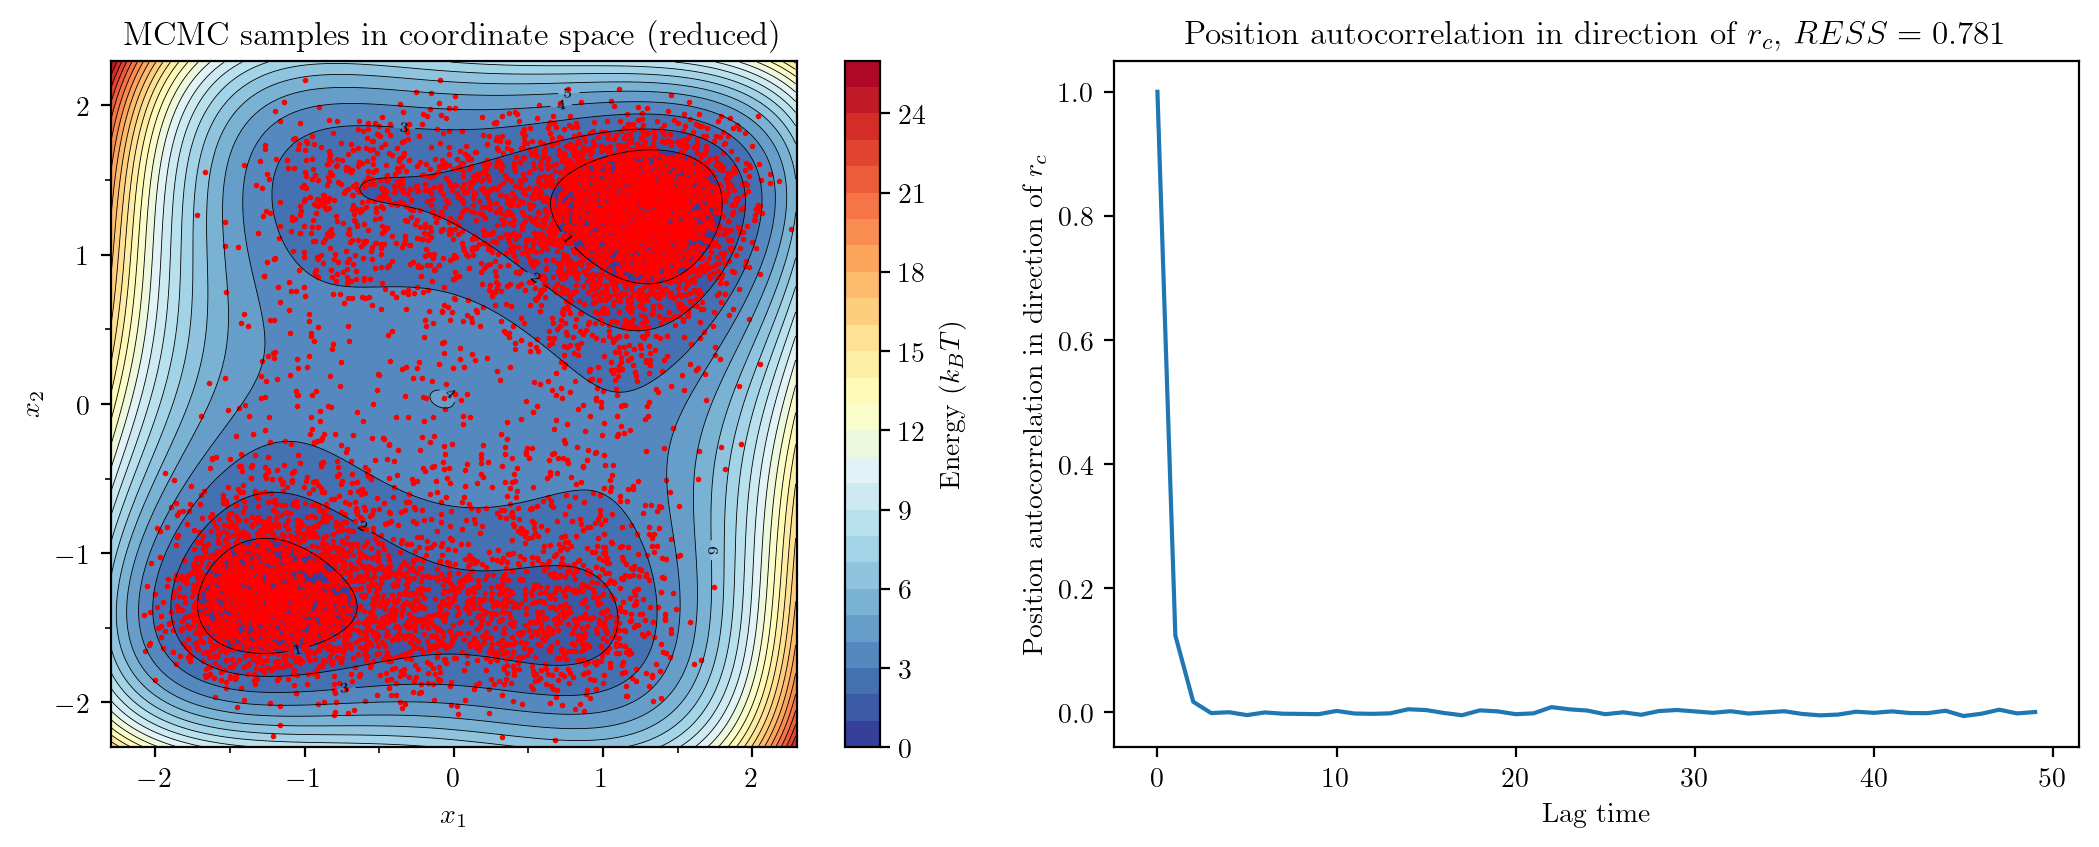

In [11]:
h = 4.0
n_samples = 100000

potential = WolfeQuapp(h=h)

trajectory = np.loadtxt(f"samples/wq_mcmc_h_{h}_nsamples_{n_samples}.csv", delimiter=",")

autocorrelation = correlate(trajectory[:, 0] + trajectory[:, 1], trajectory[:, 0] + trajectory[:, 1])
ress = effective_sample_size(trajectory[:, 0] + trajectory[:, 1], 300, tolerance=0.01)

np.random.shuffle(trajectory)
trajectory_reduced = trajectory[:7000]

fig, ax = plt.subplots(1, 2, figsize=(28*TO_CM, 11*TO_CM), dpi=200)

potential.plot_PES(fig, ax[0], title="MCMC samples in coordinate space (reduced)")

ax[0].scatter(trajectory_reduced[:, 0], trajectory_reduced[:, 1], color="red", s=1)

ax[0].set_xlim((-2.3, 2.3))
ax[0].set_ylim((-2.3, 2.3))

ax[1].plot(autocorrelation[:50])

ax[1].set_xlabel("Lag time")
ax[1].set_ylabel("Position autocorrelation in direction of $r_c$")
ax[1].set_title(f"Position autocorrelation in direction of $r_c$, $RESS = {ress:0.3f}$")

fig.tight_layout()

plt.show()

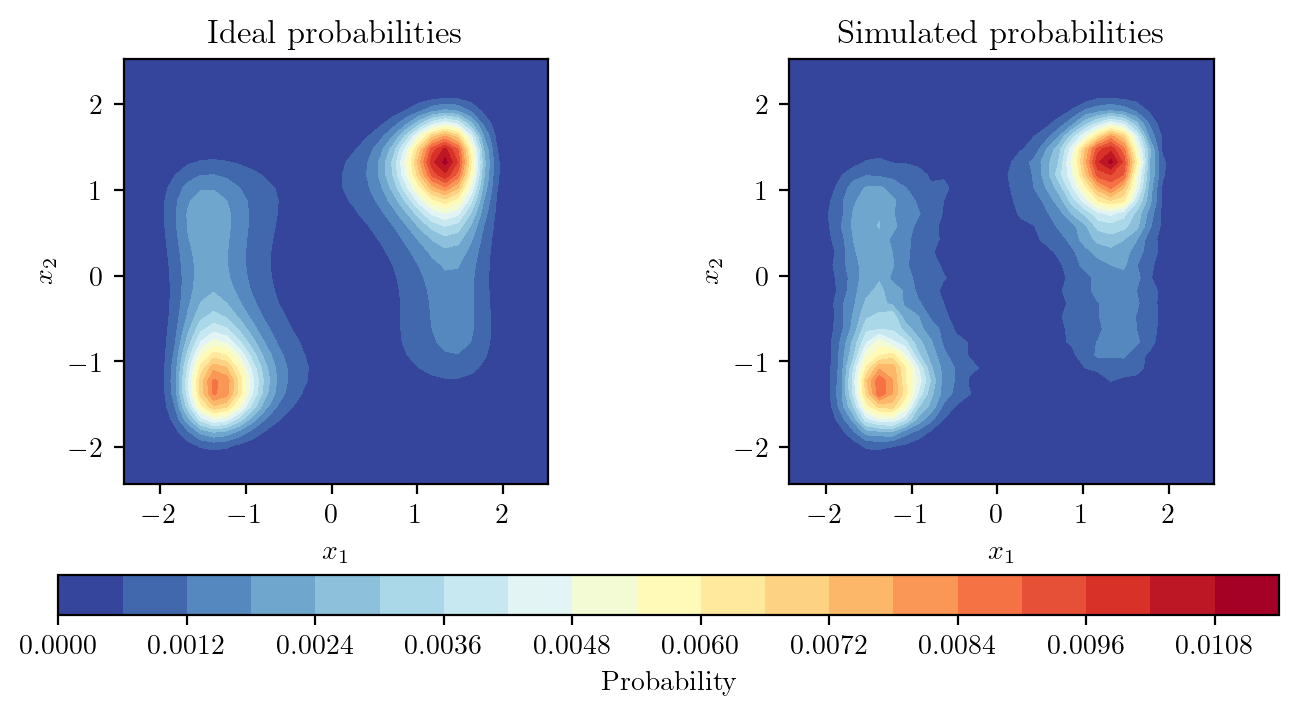

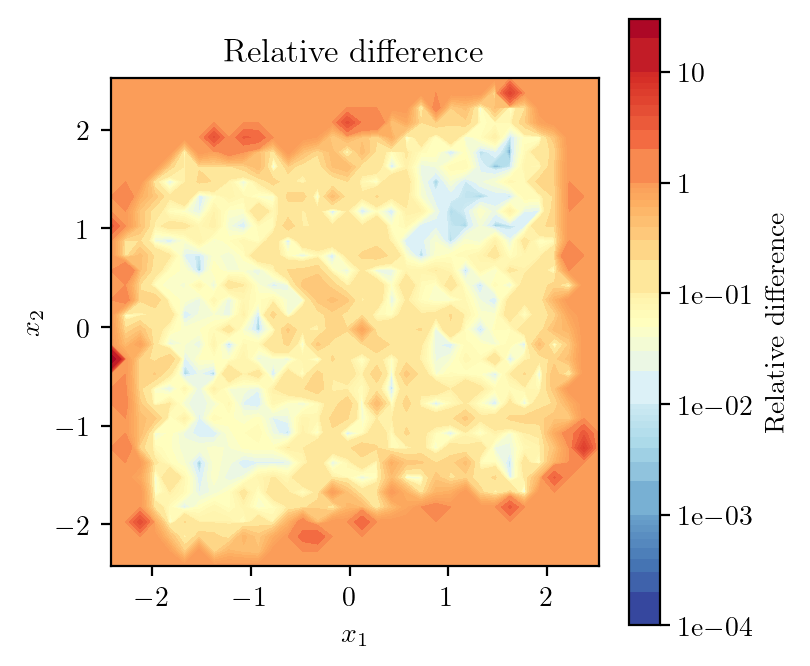

In [ ]:
h = 4.0
n_samples = 100000
dx = 0.15
xrange = 2.5

potential = WolfeQuapp(h=h)

pdf_unnormalized = lambda x, y: np.exp(-potential.evaluate(np.array([x, y])))
C = sc.integrate.dblquad(pdf_unnormalized, -np.inf, np.inf, -np.inf, np.inf)[0]
pdf = lambda x, y: pdf_unnormalized(x, y)/C

probability_ideal = lambda x, y, dx: sc.integrate.dblquad(pdf, x - dx/2, x + dx/2, y - dx/2, y + dx/2)[0]

trajectory = np.loadtxt(f"samples/wq_mcmc_h_{h}_nsamples_{n_samples}.csv", delimiter=",")

edges = np.arange(-xrange, xrange + dx, dx)
hist_trajectory = np.histogram2d(trajectory[:, 0], trajectory[:, 1], bins=(edges, edges), density=True)[0] * dx**2

centers = edges[:-1] + dx/2
X_centers, Y_centers = np.meshgrid(centers, centers)

ideal = np.zeros_like(X_centers)

for i in range(len(centers)):
    for j in range(len(centers)):
        ideal[i, j] = probability_ideal(X_centers[i, j], Y_centers[i, j], dx)

fig, ax = plt.subplots(1, 2, figsize=(20*TO_CM, 10*TO_CM), dpi=200)

vmax = max(np.max(ideal), np.max(hist_trajectory))

contour0 = ax[0].contourf(X_centers, Y_centers, ideal, cmap="RdYlBu_r", levels=20, vmin=0, vmax=vmax)
contour1 = ax[1].contourf(X_centers, Y_centers, hist_trajectory, cmap="RdYlBu_r", levels=20, vmin=0, vmax=vmax)

cbar = fig.colorbar(contour0, ax=ax[:2], orientation="horizontal", aspect=30)
cbar.set_label("Probability")

for axi in ax:
    axi.set_aspect('equal', adjustable='box')

ax[0].set_xlabel("$x_1$")
ax[0].set_ylabel("$x_2$")

ax[1].set_xlabel("$x_1$")
ax[1].set_ylabel("$x_2$")

ax[0].set_title("Ideal probabilities")
ax[1].set_title("Simulated probabilities")

plt.show()

fig, ax = plt.subplots(1, 1, figsize=(10*TO_CM, 10*TO_CM), dpi=200)

contour = ax.contourf(X_centers, Y_centers, np.abs(hist_trajectory - ideal)/ideal, cmap="RdYlBu_r", locator=matplotlib.ticker.LogLocator(subs="all"))
cbar = fig.colorbar(contour, ax=ax, format=matplotlib.ticker.LogFormatter(labelOnlyBase=True), ticks=matplotlib.ticker.LogLocator())
cbar.set_label("Relative difference")

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Relative difference")

ax.set_aspect('equal', adjustable='box')

plt.show()